<a href="https://colab.research.google.com/github/weixisee/COMP3931_Individual_Project/blob/main/1_DataPreprocessing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


unzip the file

In [ ]:
import os

dataset = "/content/drive/MyDrive/IndividualProject/cxr"

if not os.path.exists(dataset):
    !unzip "/content/drive/MyDrive/IndividualProject/cxr.zip" -d "/content/drive/MyDrive/IndividualProject/"
else:
    print("Dataset already extracted.")

Dataset already extracted.


In [ ]:
!ls /content/drive/MyDrive/IndividualProject/cxr

annotations.csv  processed_data.csv		training_loss.npy
effusion.csv	 processed_data_v3.csv		training_loss_v2.npy
images		 splits				validation_auc_atelectasis.npy
images.hdf5	 supplementary_material		validation_auc.npy
info.yaml	 task_labels			validation_auc_v2.npy
LICENSE		 teaser.png
original_splits  training_loss_atelectasis.npy


Understanding the data through annotations.csv.

In [ ]:
import pandas as pd

In [ ]:
df = pd.read_csv("/content/drive/MyDrive/IndividualProject/cxr/annotations.csv")
print(df.shape)
print(df.columns)
df.head()

(112120, 16)
Index(['filepath', 'split', 'tasks/disease labels', 'tasks/patient sex',
       'original_filepath', 'original_split', 'patient_id', 'bounding_box',
       'disease labels', 'finding_labels', 'follow-up_nb',
       'original_image_size', 'original_pixel_spacing', 'patient sex',
       'patient_age', 'view_position'],
      dtype='object')


,filepath,split,tasks/disease labels,tasks/patient sex,original_filepath,original_split,patient_id,bounding_box,disease labels,finding_labels,follow-up_nb,original_image_size,original_pixel_spacing,patient sex,patient_age,view_position
0,images/000000.tiff,train,"[0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]",1,images/00000001_000.png,train,1,NaN,Cardiomegaly,Cardiomegaly,0,"(2682,2749)","(0.143,0.143)",M,57,PA
1,images/000001.tiff,train,"[0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0]",1,images/00000001_001.png,train,1,NaN,Cardiomegaly|Emphysema,Cardiomegaly|Emphysema,1,"(2894,2729)","(0.143,0.143)",M,58,PA
2,images/000002.tiff,train,"[0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]",1,images/00000001_002.png,train,1,NaN,Cardiomegaly|Effusion,Cardiomegaly|Effusion,2,"(2500,2048)","(0.168,0.168)",M,58,PA
3,images/000003.tiff,train,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]",1,images/00000002_000.png,train,2,NaN,NaN,No Finding,0,"(2500,2048)","(0.171,0.171)",M,80,PA
4,images/000004.tiff,test,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1]",0,images/00000003_001.png,test,3,NaN,Hernia,Hernia,0,"(2500,2048)","(0.168,0.168)",F,74,PA


In [ ]:
import yaml

with open("/content/drive/MyDrive/IndividualProject/cxr/info.yaml", "r") as f:
    info = yaml.safe_load(f)

info.keys()


dict_keys(['id', 'name', 'summary', 'domain', 'tasks', 'input_size', 'total_num_samples', 'splits_num_samples', 'original_splits_num_samples', 'domain_overlaps', 'subject_overlaps', 'license', 'project_website', 'download_url', 'DOI', 'original_data'])

In [ ]:
# convert the disease labels column values from string to list
import ast

disease_names = info['tasks'][0]['labels']
df["tasks/disease labels"] = df["tasks/disease labels"].apply(ast.literal_eval)

In [ ]:
disease_counts = {}

for idx, name in disease_names.items():
    disease_counts[name] = df["tasks/disease labels"].apply(lambda x: x[idx] == 1).sum()

In [ ]:
pd.DataFrame.from_dict(disease_counts, orient="index", columns=["positive_cases"]) \
  .sort_values("positive_cases", ascending=False)

,positive_cases
Infiltration,19894
Effusion,13317
Atelectasis,11559
Nodule,6331
Mass,5782
Pneumothorax,5302
Consolidation,4667
Pleural_Thickening,3385
Cardiomegaly,2776
Emphysema,2516


In [ ]:

num_no_finding = (df['finding_labels'] == 'No Finding').sum()

print(num_no_finding)


60361


In [ ]:
df["tasks/atelectasis_label"] = df["disease labels"].str.contains("Atelectasis", na=False).astype(int)
df["tasks/pneumonia_label"] = df["disease labels"].str.contains("Pneumonia", na=False).astype(int)

In [ ]:
df["tasks/atelectasis_label"].value_counts(normalize=True)

,proportion
tasks/atelectasis_label,
0,0.896905
1,0.103095


In [ ]:
df["tasks/pneumonia_label"].value_counts(normalize=True)

,proportion
tasks/pneumonia_label,
0,0.987237
1,0.012763


In [ ]:
# include binary column for effusion
df["tasks/effusion_label"] = df["disease labels"].str.contains("Effusion", na=False).astype(int)

In [ ]:
df["tasks/effusion_label"].value_counts()


,count
tasks/effusion_label,
0,98803
1,13317


In [ ]:
pd.crosstab(
    df["tasks/effusion_label"],
    df["patient sex"],
    normalize="index"
)


patient sex,F,M
tasks/effusion_label,,
0,0.434177,0.565823
1,0.441691,0.558309


In [ ]:
pd.crosstab(
    df["tasks/atelectasis_label"],
    df["patient sex"],
    normalize="index"
)

patient sex,F,M
tasks/atelectasis_label,,
0,0.438808,0.561192
1,0.402543,0.597457


In [ ]:
pd.crosstab(
    df["tasks/pneumonia_label"],
    df["patient sex"],
    normalize="index"
)

patient sex,F,M
tasks/pneumonia_label,,
0,0.435337,0.564663
1,0.414396,0.585604


In [ ]:
df.head()

,filepath,split,tasks/disease labels,tasks/patient sex,original_filepath,original_split,patient_id,bounding_box,disease labels,finding_labels,follow-up_nb,original_image_size,original_pixel_spacing,patient sex,patient_age,view_position,tasks/atelectasis_label,tasks/pneumonia_label
0,images/000000.tiff,train,"[0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]",1,images/00000001_000.png,train,1,NaN,Cardiomegaly,Cardiomegaly,0,"(2682,2749)","(0.143,0.143)",M,57,PA,0,0
1,images/000001.tiff,train,"[0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0]",1,images/00000001_001.png,train,1,NaN,Cardiomegaly|Emphysema,Cardiomegaly|Emphysema,1,"(2894,2729)","(0.143,0.143)",M,58,PA,0,0
2,images/000002.tiff,train,"[0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]",1,images/00000001_002.png,train,1,NaN,Cardiomegaly|Effusion,Cardiomegaly|Effusion,2,"(2500,2048)","(0.168,0.168)",M,58,PA,0,0
3,images/000003.tiff,train,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]",1,images/00000002_000.png,train,2,NaN,NaN,No Finding,0,"(2500,2048)","(0.171,0.171)",M,80,PA,0,0
4,images/000004.tiff,test,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1]",0,images/00000003_001.png,test,3,NaN,Hernia,Hernia,0,"(2500,2048)","(0.168,0.168)",F,74,PA,0,0


In [ ]:
df['tasks/patient sex'].value_counts(normalize=True)

,proportion
tasks/patient sex,
1,0.56493
0,0.43507


In [ ]:
!ls /content/drive/MyDrive/IndividualProject/cxr/task_labels

'disease labels.npy'  'patient sex.npy'


In [ ]:
import numpy as np

labels = np.load("/content/drive/MyDrive/IndividualProject/cxr/task_labels/disease labels.npy")
sex = np.load("/content/drive/MyDrive/IndividualProject/cxr/task_labels/patient sex.npy")

print(labels.shape, sex.shape)


(112120, 14) (112120,)


In [ ]:
info

{'id': 'cxr',
 'name': 'Chest X-ray Multi-disease',
 'summary': 'Chest X-ray dataset containing 112,120 frontal-view X-ray images with annotations for 14 common thorax diseases',
 'domain': 'Chest X-ray',
 'tasks': [{'task_name': 'disease labels',
   'task_target': 'MULTILABEL_CLASSIFICATION',
   'labels': {0: 'Atelectasis',
    1: 'Cardiomegaly',
    2: 'Effusion',
    3: 'Infiltration',
    4: 'Mass',
    5: 'Nodule',
    6: 'Pneumonia',
    7: 'Pneumothorax',
    8: 'Consolidation',
    9: 'Edema',
    10: 'Emphysema',
    11: 'Fibrosis',
    12: 'Pleural_Thickening',
    13: 'Hernia'}},
  {'task_name': 'patient sex',
   'task_target': 'BINARY_CLASSIFICATION',
   'labels': {0: 'F', 1: 'M'}}],
 'input_size': [1, 224, 224],
 'total_num_samples': 112120,
 'splits_num_samples': {'train': 73421, 'val': 13103, 'test': 25596},
 'original_splits_num_samples': {'train': 86524, 'val': 0, 'test': 25596},
 'domain_overlaps': ['pneumonia'],
 'subject_overlaps': [],
 'license': 'Creative Commons 

In [ ]:
# try to load images and verify it is 224x224 pixels
import h5py
import random

with h5py.File("/content/drive/MyDrive/IndividualProject/cxr/images.hdf5", "r") as f:
  print("Keys in HDF5", list(f.keys()))

  images = f['images']
  random_index = random.randint(0, len(images) - 1)
  random_image = images[random_index]

  print("Random index:", random_index)
  print("Image shape:", random_image.shape)

Keys in HDF5 ['images']
Random index: 53622
Image shape: (224, 224)


In [ ]:
print("Data type:", random_image.dtype)
print("Min/Max value:", random_image.min(), "/", random_image.max())

Data type: uint8
Min/Max value: 0 / 242


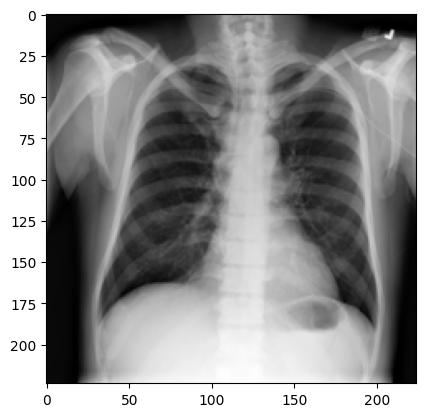

In [ ]:
# visualise the image
import matplotlib.pyplot as plt

plt.imshow(random_image, cmap='gray')
plt.show()

To verify the train-test-validation split

In [ ]:
!ls /content/drive/MyDrive/IndividualProject/cxr/splits

test.txt  train.txt  val.txt


In [ ]:
with open("/content/drive/MyDrive/IndividualProject/cxr/splits/train.txt") as f:
    for _ in range(5):
        print(f.readline().strip())

images/000000.tiff
images/000001.tiff
images/000002.tiff
images/000003.tiff
images/000012.tiff


In [ ]:
def load_split(path):
    with open(path, "r") as f:
        return set(line.strip() for line in f)

split_dir = "/content/drive/MyDrive/IndividualProject/cxr/splits"

train_ids = load_split(f"{split_dir}/train.txt")
val_ids   = load_split(f"{split_dir}/val.txt")
test_ids  = load_split(f"{split_dir}/test.txt")

print("Train size:", len(train_ids))
print("Val size:", len(val_ids))
print("Test size:", len(test_ids))


Train size: 73421
Val size: 13103
Test size: 25596


In [ ]:
# total number of cases
total = len(train_ids) + len(val_ids) + len(test_ids)
print("Total cases:", total)

Total cases: 112120


In [ ]:
# verify the percentage of the split
train_pct = 100 * len(train_ids) / total
val_pct   = 100 * len(val_ids) / total
test_pct  = 100 * len(test_ids) / total

print(f"Train: {len(train_ids)} ({train_pct:.2f}%)")
print(f"Val:   {len(val_ids)} ({val_pct:.2f}%)")
print(f"Test:  {len(test_ids)} ({test_pct:.2f}%)")

Train: 73421 (65.48%)
Val:   13103 (11.69%)
Test:  25596 (22.83%)


In [ ]:
print("Train ∩ Val:", len(train_ids & val_ids))
print("Train ∩ Test:", len(train_ids & test_ids))
print("Val ∩ Test:", len(val_ids & test_ids))


Train ∩ Val: 0
Train ∩ Test: 0
Val ∩ Test: 0


To identify the total number of cases for each disease labels.

Identify the distribution of male and female in the dataset.

In [ ]:
# identify the distribution of male and female
df['patient sex'].value_counts(normalize=True)

,proportion
patient sex,
M,0.56493
F,0.43507


Identify the distribution of patients' age in the dataset.

In [ ]:
# the age are grouped into three (people less than 40 years old, patients between 40 to 64 years old and patients of 65 years old and above)
bins = [-float('inf'), 40, 65, float('inf')]
age_labels = ['<40', '40-65', '>65']

df['patient_age_group'] = pd.cut(df['patient_age'], bins=bins, labels=age_labels, right=False)

In [ ]:
df['patient_age_group'].value_counts()
df['patient_age_group'].value_counts(normalize=True)

,proportion
patient_age_group,
40-65,0.536336
<40,0.325000
>65,0.138664


In [ ]:
# the age are grouped into three (people less than 40 years old, patients between 40 to 64 years old and patients of 65 years old and above)
bins = [-float('inf'), 20, 40, 60, 80, float('inf')]
age_labels = ['<=20', '21-40', '41-60', '61-80', '>80']

df['patient_age_group'] = pd.cut(df['patient_age'], bins=bins, labels=age_labels, right=False)

In [ ]:
df['patient_age_group'].value_counts()
df['patient_age_group'].value_counts(normalize=True)

,proportion
patient_age_group,
41-60,0.439199
21-40,0.262157
61-80,0.226712
<=20,0.062843
>80,0.009088


In [ ]:
print(df['patient_age'].describe())
print(df['patient_age_group'].value_counts())

count    112120.000000
mean         46.626365
std          16.602680
min           0.000000
25%          34.000000
50%          49.000000
75%          59.000000
max          95.000000
Name: patient_age, dtype: float64
patient_age_group
41-60    49243
21-40    29393
61-80    25419
<=20      7046
>80       1019
Name: count, dtype: int64


In [ ]:
# check distribution at different thresholds
for threshold in [40, 45, 49, 50, 55, 60]:
    young = (df['patient_age'] <= threshold).sum()
    older = (df['patient_age'] > threshold).sum()
    print(f"Threshold {threshold}: younger={young} ({young/len(df)*100:.1f}%), older={older} ({older/len(df)*100:.1f}%)")

Threshold 40: younger=38385 (34.2%), older=73735 (65.8%)
Threshold 45: younger=48696 (43.4%), older=63424 (56.6%)
Threshold 49: younger=58341 (52.0%), older=53779 (48.0%)
Threshold 50: younger=60568 (54.0%), older=51552 (46.0%)
Threshold 55: younger=74464 (66.4%), older=37656 (33.6%)
Threshold 60: younger=88031 (78.5%), older=24089 (21.5%)


In [ ]:
# for atelectasis
pd.crosstab(
    df['tasks/atelectasis_label'],
    df['patient_age_group'],
    normalize='index'
)

patient_age_group,<40,40-65,>65
tasks/atelectasis_label,,,
0,0.335647,0.530255,0.134098
1,0.232373,0.589238,0.178389


Identify the count for each split - to identify the percentage of the split

In [ ]:
df['split'].value_counts(normalize=True)

,proportion
split,
train,0.654843
test,0.228291
val,0.116866


In [ ]:
# check the distribution of patient's sex and age among each split
df.groupby('split')['patient sex'].value_counts(normalize=True)

split  patient sex
test   M              0.581419
       F              0.418581
train  M              0.557620
       F              0.442380
val    M              0.573685
       F              0.426315
Name: proportion, dtype: float64

In [ ]:
# 'normalize=index' means "calculate percentages across the rows"
result = pd.crosstab(df['split'], df['patient sex'], normalize='index')

In [ ]:
df.groupby('split')['patient_age_group'].value_counts(normalize=True)

split  patient_age_group
test   40-65                0.527114
       <40                  0.328606
       >65                  0.144280
train  40-65                0.533158
       <40                  0.329143
       >65                  0.137699
val    40-65                0.572159
       <40                  0.294742
       >65                  0.133099
Name: proportion, dtype: float64

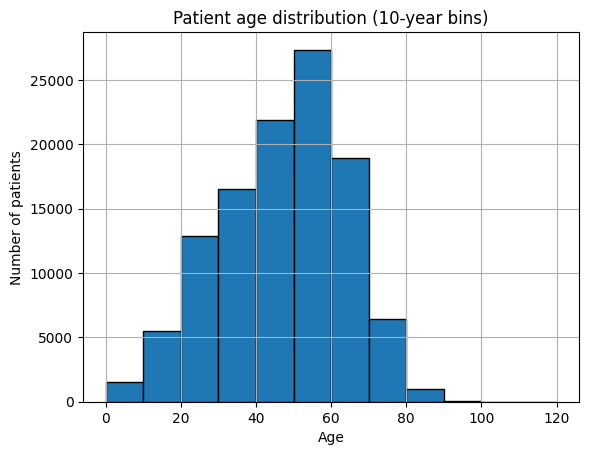

In [ ]:
import matplotlib.pyplot as plt

df['patient_age'].dropna().hist(
    bins=range(0, 121, 10),  # 0–10, 10–20, ..., 110–120
    edgecolor='black'
)

plt.xlabel("Age")
plt.ylabel("Number of patients")
plt.title("Patient age distribution (10-year bins)")
plt.show()


In [ ]:
df.columns

Index(['filepath', 'split', 'tasks/disease labels', 'tasks/patient sex',
       'original_filepath', 'original_split', 'patient_id', 'bounding_box',
       'disease labels', 'finding_labels', 'follow-up_nb',
       'original_image_size', 'original_pixel_spacing', 'patient sex',
       'patient_age', 'view_position', 'patient_age_group'],
      dtype='object')

In [ ]:
df.to_csv("/content/drive/MyDrive/IndividualProject/cxr/processed_data.csv", index=False)

In [ ]:
df.to_csv("/content/drive/MyDrive/IndividualProject/cxr/effusion.csv", index=False)

In [ ]:
df.to_csv("/content/drive/MyDrive/IndividualProject/cxr/processed_data_v3.csv", index=False)

In [ ]:
processed_data_v3 = pd.read_csv("/content/drive/MyDrive/IndividualProject/cxr/processed_data_v3.csv")
processed_data_v3.columns
processed_data_v3.head()

,filepath,split,tasks/disease labels,tasks/patient sex,original_filepath,original_split,patient_id,bounding_box,disease labels,finding_labels,follow-up_nb,original_image_size,original_pixel_spacing,patient sex,patient_age,view_position,tasks/atelectasis_label,tasks/pneumonia_label
0,images/000000.tiff,train,"[0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]",1,images/00000001_000.png,train,1,NaN,Cardiomegaly,Cardiomegaly,0,"(2682,2749)","(0.143,0.143)",M,57,PA,0,0
1,images/000001.tiff,train,"[0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0]",1,images/00000001_001.png,train,1,NaN,Cardiomegaly|Emphysema,Cardiomegaly|Emphysema,1,"(2894,2729)","(0.143,0.143)",M,58,PA,0,0
2,images/000002.tiff,train,"[0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]",1,images/00000001_002.png,train,1,NaN,Cardiomegaly|Effusion,Cardiomegaly|Effusion,2,"(2500,2048)","(0.168,0.168)",M,58,PA,0,0
3,images/000003.tiff,train,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]",1,images/00000002_000.png,train,2,NaN,NaN,No Finding,0,"(2500,2048)","(0.171,0.171)",M,80,PA,0,0
4,images/000004.tiff,test,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1]",0,images/00000003_001.png,test,3,NaN,Hernia,Hernia,0,"(2500,2048)","(0.168,0.168)",F,74,PA,0,0


In [ ]:
effusion_df = pd.read_csv("/content/drive/MyDrive/IndividualProject/cxr/effusion.csv")
effusion_df.columns
effusion_df.head()

,filepath,split,tasks/disease labels,tasks/patient sex,original_filepath,original_split,patient_id,bounding_box,disease labels,finding_labels,follow-up_nb,original_image_size,original_pixel_spacing,patient sex,patient_age,view_position,tasks/effusion_label
0,images/000000.tiff,train,"[0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]",1,images/00000001_000.png,train,1,NaN,Cardiomegaly,Cardiomegaly,0,"(2682,2749)","(0.143,0.143)",M,57,PA,0
1,images/000001.tiff,train,"[0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0]",1,images/00000001_001.png,train,1,NaN,Cardiomegaly|Emphysema,Cardiomegaly|Emphysema,1,"(2894,2729)","(0.143,0.143)",M,58,PA,0
2,images/000002.tiff,train,"[0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]",1,images/00000001_002.png,train,1,NaN,Cardiomegaly|Effusion,Cardiomegaly|Effusion,2,"(2500,2048)","(0.168,0.168)",M,58,PA,1
3,images/000003.tiff,train,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]",1,images/00000002_000.png,train,2,NaN,NaN,No Finding,0,"(2500,2048)","(0.171,0.171)",M,80,PA,0
4,images/000004.tiff,test,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1]",0,images/00000003_001.png,test,3,NaN,Hernia,Hernia,0,"(2500,2048)","(0.168,0.168)",F,74,PA,0


In [ ]:
# define Youden's threshold
def youden_threshold(y_true, y_prob):
  fpr_val, tpr_val, thresholds = roc_curve(y_true, y_prob)

  j_scores = tpr_val - fpr_val
  youden_index = np.argmax(j_scores)
  optimal_threshold = thresholds[youden_index]

  return optimal_threshold

In [ ]:
def gender_disparity(y_prob, y_true, df, threshold):

  # initialise a dictionaries to store the result
  disparities = {}

  y_pred = (y_prob >= threshold).astype(int)

  male_group = (df['tasks/patient sex'] == 1).to_numpy()
  female_group = (df['tasks/patient sex'] == 0).to_numpy()

  # group them baseed on male/female
  male_preds = y_pred[male_group]
  male_true = y_true[male_group]

  female_preds = y_pred[female_group]
  female_true = y_true[female_group]

  # compute the tpr for male and female group
  # male_fpr, male_tpr = roc_curve(male_true, male_preds, average='binary')
  # female_fpr, female_tpr = roc_curve(female_true, female_preds, average='binary')
  male_tpr = recall_score(male_true, male_preds)
  female_tpr = recall_score(female_true, female_preds)

  # compute the difference
  # this will shows a negative result if female group is disadvantaged
  tpr_disparity = female_tpr - male_tpr
  # fpr_disparity = female_fpr - male_fpr

  disparities["atelectasis"] = {
    'tpr_male': round(float(male_tpr), 4),
    'tpr_female': round(float(female_tpr), 4),
    'tpr_disparity': round(float(tpr_disparity), 4),
    # 'fpr_male': round(float(male_fpr), 4),
    # 'fpr_female': round(float(female_fpr), 4),
    # 'fpr_disparity': round(float(fpr_disparity), 4),
    'male_samples': int(male_group.sum()),
    'female_samples': int(female_group.sum()),
    'total_samples': int(len(y_pred))
  }



  return disparities

In [ ]:
def auc_by_sex(y_prob, y_true, df):

    results = {}

    male_group = (df['tasks/patient sex'] == 1).to_numpy()
    female_group = (df['tasks/patient sex'] == 0).to_numpy()

    male_true = y_true[male_group]
    male_prob = y_prob[male_group]

    female_true = y_true[female_group]
    female_prob = y_prob[female_group]

    auc_male = roc_auc_score(male_true, male_prob)
    auc_female = roc_auc_score(female_true, female_prob)

    auc_gap = abs(auc_male - auc_female)

    results["atelectasis"] = {
    "auc_male": round(float(auc_male), 4),
    "auc_female": round(float(auc_female), 4),
    "auc_gap": round(float(auc_gap), 4)
  }


    return results


In [ ]:
# split the age into different age group
test_df = test_df.copy()
bins = [0, 40, 65, 120]
labels = ["<40", '40-65', '>65']
test_df['age_group'] = pd.cut(test_df['patient_age'], bins=bins, labels=labels, right=False)

# measuring age disparity
def age_disparity(y_true, y_prob, df, threshold):

  disparities = {}
  y_pred = (y_prob >= threshold).astype(int)

  age_groups = {
        '<40': (df['age_group'] == '<40').to_numpy(),
        '40-65': (df['age_group'] == '40-65').to_numpy(),
        '>65': (df['age_group'] == '>65').to_numpy()
    }

  tpr_per_group = {}
  fpr_per_group = {}

  for group_name, group_mask in age_groups.items():
    group_preds = y_pred[group_mask]
    group_true = y_true[group_mask]
    tpr = recall_score(group_true, group_preds)
    tpr_per_group[group_name] = tpr
    # fpr_per_group[group_name] = fpr

  median_tpr = np.nanmedian(list(tpr_per_group.values()))
  # median_fpr = np.nanmedian(list(fpr_per_group.values()))

  for group_name, mask in age_groups.items():
    disparities[group_name] = {
        'tpr': round(float(tpr_per_group[group_name]), 4),
        # 'fpr': round(float(fpr_per_group[group_name]), 4),
        'tpr_disparity': round(float(tpr_per_group[group_name] - median_tpr), 4),
        # 'fpr_disparity': round(float(fpr_per_group[group_name] - median_fpr), 4),
        'n_samples': int(mask.sum()),
        'n_pos': int(y_true[mask].sum())
    }

  return disparities